🚀 Starting Data Processing Workflow...
✅ All 6 dataset files loaded successfully!
📊 Rendering final analytical dashboard visualizations...


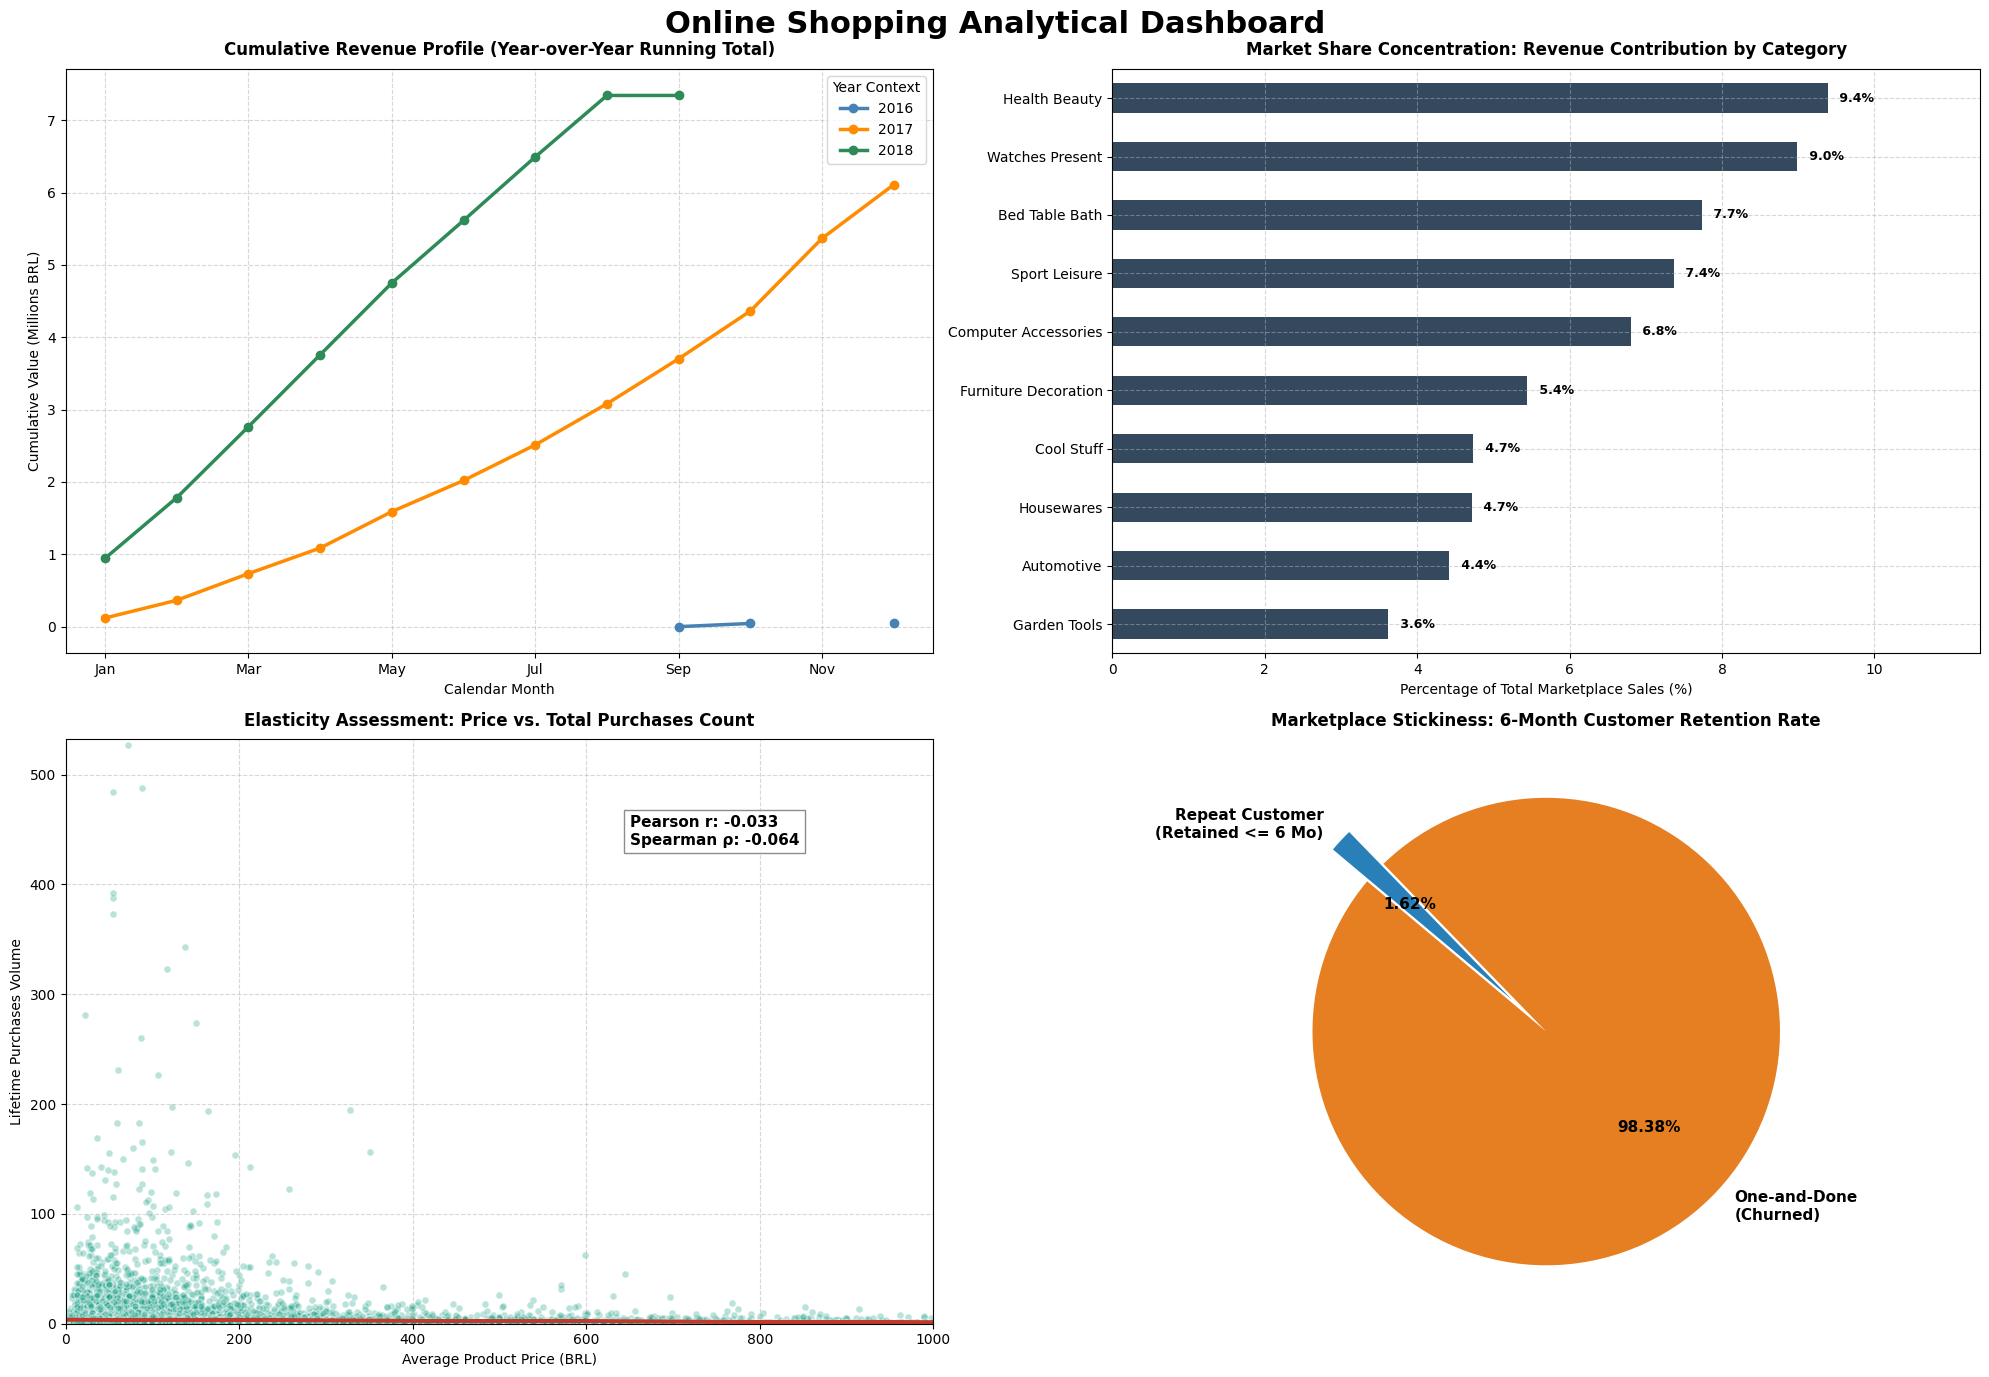

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("🚀 Starting Data Processing Workflow...")

# =========================================================================
# 1. LOAD THE REAL FILE PIPELINES
# =========================================================================
try:
    df_customers = pd.read_csv('customers.csv', encoding='latin1')
    df_orders = pd.read_csv('orders.csv', encoding='latin1')
    df_items = pd.read_csv('order_items.csv', encoding='latin1')
    df_payments = pd.read_csv('payments.csv', encoding='latin1')
    df_products = pd.read_csv('products.csv', encoding='latin1')
    df_sellers = pd.read_csv('sellers.csv', encoding='latin1')
    print("✅ All 6 dataset files loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error: Missing file in directory. Detail: {e}")
    print("Ensure all CSV filenames match Olist specifications and sit in this workspace.")
    raise

# Clean dates and filter out invalid/unfulfilled order entries upfront
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_clean_orders = df_orders[~df_orders['order_status'].isin(['canceled', 'unavailable'])].copy()

# =========================================================================
# 2. DATA PROCESSING FOR METRIC 1: CUMULATIVE SALES PER MONTH
# =========================================================================
df_clean_orders['year'] = df_clean_orders['order_purchase_timestamp'].dt.year
df_clean_orders['month_num'] = df_clean_orders['order_purchase_timestamp'].dt.month
df_clean_orders['month_name'] = df_clean_orders['order_purchase_timestamp'].dt.strftime('%b')

sales_merged = df_clean_orders.merge(df_items, on='order_id', how='inner')
monthly_sales = sales_merged.groupby(['year', 'month_num', 'month_name'])['price'].sum().reset_index()
monthly_sales['cumulative_sales'] = monthly_sales.groupby('year')['price'].cumsum() / 1e6 # Convert to millions

# Pivot table for Line Chart plotting
df_cum_pivot = monthly_sales.pivot(index='month_num', columns='year', values='cumulative_sales')
month_labels = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df_cum_pivot.index = df_cum_pivot.index.map(month_labels)

# =========================================================================
# 3. DATA PROCESSING FOR METRIC 2: MARKET SHARE CONTRIBUTION BY CATEGORY
# =========================================================================
cat_merged = df_items.merge(df_products, on='product_id', how='inner')
category_revenue = cat_merged.groupby('product_category')['price'].sum().reset_index()
total_marketplace_revenue = category_revenue['price'].sum()
category_revenue['contribution_pct'] = (category_revenue['price'] / total_marketplace_revenue) * 100

# Format labels and pull top 10 categories
category_revenue['product_category'] = category_revenue['product_category'].str.replace('_', ' ').str.title()
top_10_categories = category_revenue.sort_values(by='contribution_pct', ascending=True).tail(10)

# =========================================================================
# 4. DATA PROCESSING FOR METRIC 3: PRICE VS. PURCHASES CORRELATION
# =========================================================================
product_metrics = df_items.groupby('product_id').agg(
    avg_price=('price', 'mean'),
    purchase_count=('order_id', 'count')
).reset_index()

# Filter out high extreme pricing anomalies over 1000 BRL to protect chart bounds
product_metrics_clean = product_metrics[product_metrics['avg_price'] <= 1000]
pearson_r = product_metrics_clean['avg_price'].corr(product_metrics_clean['purchase_count'], method='pearson')
spearman_rho = product_metrics_clean['avg_price'].corr(product_metrics_clean['purchase_count'], method='spearman')

# =========================================================================
# 5. DATA PROCESSING FOR METRIC 4: 6-MONTH RETENTION WINDOW DIAGNOSTIC
# =========================================================================
user_orders = df_clean_orders.merge(df_customers, on='customer_id', how='inner')
user_orders['first_purchase'] = user_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')
user_orders['days_since_first'] = (user_orders['order_purchase_timestamp'] - user_orders['first_purchase']).dt.days

user_orders['is_retained_6m'] = (user_orders['days_since_first'] > 0) & (user_orders['days_since_first'] <= 180)
retention_summary = user_orders.groupby('customer_unique_id')['is_retained_6m'].max().reset_index()

retained_count = retention_summary['is_retained_6m'].sum()
churned_count = len(retention_summary) - retained_count
retention_percentages = [churned_count, retained_count]

# =========================================================================
# 6. INITIALIZE MULTI-PLOT CANVAS DASHBOARD
# =========================================================================
plt.style.use('default')
plt.rcParams.update({'font.size': 10, 'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.5})

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Online Shopping Analytical Dashboard", fontsize=22, fontweight='bold', y=0.98)

# PLOT 1: Cumulative Sales Trend Per Year
df_cum_pivot.plot(kind='line', ax=axes[0, 0], marker='o', linewidth=2.5, color=['#4682B4', '#FF8C00', '#2E8B57'])
axes[0, 0].set_title("Cumulative Revenue Profile (Year-over-Year Running Total)", fontweight='bold', pad=10)
axes[0, 0].set_ylabel("Cumulative Value (Millions BRL)")
axes[0, 0].set_xlabel("Calendar Month")
axes[0, 0].legend(title="Year Context")

# PLOT 2: Category Market Share Breakdown
top_10_categories.plot(kind='barh', x='product_category', y='contribution_pct', ax=axes[0, 1], color='#34495E', legend=False)
for index, value in enumerate(top_10_categories['contribution_pct']):
    axes[0, 1].text(value + 0.1, index, f" {value:.1f}%", va='center', fontweight='bold', fontsize=9)
axes[0, 1].set_title("Market Share Concentration: Revenue Contribution by Category", fontweight='bold', pad=10)
axes[0, 1].set_xlabel("Percentage of Total Marketplace Sales (%)")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlim(0, top_10_categories['contribution_pct'].max() + 2)

# PLOT 3: Product Price vs. Transaction Sales Volumes
axes[1, 0].scatter(product_metrics_clean['avg_price'], product_metrics_clean['purchase_count'], alpha=0.3, color='#16A085', edgecolors='w', s=25)
m, b = np.polyfit(product_metrics_clean['avg_price'], product_metrics_clean['purchase_count'], 1)
axes[1, 0].plot(product_metrics_clean['avg_price'], m*product_metrics_clean['avg_price'] + b, color='#C0392B', linewidth=2.5)
axes[1, 0].set_title("Elasticity Assessment: Price vs. Total Purchases Count", fontweight='bold', pad=10)
axes[1, 0].set_xlabel("Average Product Price (BRL)")
axes[1, 0].set_ylabel("Lifetime Purchases Volume")
axes[1, 0].set_xlim(0, 1000)
axes[1, 0].set_ylim(0, product_metrics_clean['purchase_count'].max() + 5)
stats_box = f"Pearson r: {pearson_r:.3f}\nSpearman ρ: {spearman_rho:.3f}"
axes[1, 0].text(0.65, 0.82, stats_box, transform=axes[1, 0].transAxes, fontweight='bold', fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

# PLOT 4: 6-Month Retention Window Diagnostic
axes[1, 1].pie(retention_percentages, labels=['One-and-Done\n(Churned)', 'Repeat Customer\n(Retained <= 6 Mo)'],
               autopct='%1.2f%%', startangle=140, colors=['#E67E22', '#2980B9'], explode=(0, 0.2), textprops={'fontweight':'bold', 'fontsize':11})
axes[1, 1].set_title("Marketplace Stickiness: 6-Month Customer Retention Rate", fontweight='bold', pad=10)
axes[1, 1].grid(False) # Turn off grid specifically for the pie layout canvas

# Clean up window allocations and paint the screen
plt.tight_layout()
print("📊 Rendering final analytical dashboard visualizations...")
plt.show()
